# 📊 ARTE Chatbot - Reporte de Calidad

Este notebook genera un reporte interactivo de calidad del chatbot, comparando las métricas entre {sprint_a} (baseline) y {sprint_b} (final).

**Métricas incluidas:**
- Latencia promedio
- Tasa de escalamiento
- Precisión técnica
- Tasa de alucinación

**Datos:** Se leen desde S3 (`evaluation/reports/`). Si no hay datos disponibles, se utilizan datos mock para demostración.

In [1]:
# %pip install plotly boto3 pandas numpy kaleido

In [2]:
import os
import json
import sys
from pathlib import Path
from datetime import datetime

import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import ipywidgets as widgets
from IPython.display import display, clear_output

# Intentar importar S3 client
try:
    from evaluation.s3_client import S3ReportsClient
    S3_AVAILABLE = True
except ImportError:
    S3_AVAILABLE = False
    print("⚠️ S3 client no disponible. Usando solo datos mock.")

sys.path.insert(0, '/home/creep/workshop/chatbot-25')

⚠️ S3 client no disponible. Usando solo datos mock.


## 1. Selección de Sprints

In [3]:
def discover_available_sprints() -> list[str]:
    """Discover available sprints from S3 or local mock data."""
    # Guard: ensure S3_AVAILABLE is defined (may not exist if cell executed out of order)
    try:
        S3_AVAILABLE
    except NameError:
        S3_AVAILABLE = False
    
    sprints = []
    
    # Try S3 first
    if S3_AVAILABLE:
        try:
            client = S3ReportsClient()
            sprints = client.list_sprints()
            print(f"Sprints encontrados en S3: {sprints}")
        except Exception as e:
            print(f"⚠️ Error al conectar a S3: {e}")
    
    # Fallback to mock data
    if not sprints:
        try:
            from evaluation.mock_data_generator import list_mock_sprints
            sprints = list_mock_sprints()
            print(f"Sprints encontrados en mock data: {sprints}")
        except ImportError:
            pass
    
    # Default fallback
    if not sprints:
        sprints = ["sprint_2", "sprint_5"]
        print(f"Usando sprints por defecto: {sprints}")
    
    return sprints

available_sprints = discover_available_sprints()

sprint_selector_output = widgets.Output()

sprint_a_dropdown = widgets.Dropdown(
    options=available_sprints,
    value=available_sprints[0] if len(available_sprints) > 0 else None,
    description='Sprint A:',
    style={'description_width': 'initial'}
)

sprint_b_dropdown = widgets.Dropdown(
    options=available_sprints,
    value=available_sprints[1] if len(available_sprints) > 1 else available_sprints[0] if available_sprints else None,
    description='Sprint B:',
    style={'description_width': 'initial'}
)

def update_colors(change):
    sprint_a = sprint_a_dropdown.value
    sprint_b = sprint_b_dropdown.value
    global colors
    colors = {
        "sprint_a": "#FF6B6B",
        "sprint_b": "#4ECDC4",
        sprint_a: "#FF6B6B",
        sprint_b: "#4ECDC4",
        "improvement": "#95E1D3",
        "decline": "#F38181"
    }

sprint_a_dropdown.observe(update_colors, names='value')
sprint_b_dropdown.observe(update_colors, names='value')

display(widgets.HBox([sprint_a_dropdown, sprint_b_dropdown]))
display(sprint_selector_output)

Usando sprints por defecto: ['sprint_2', 'sprint_5']


Output()

## 2. Configuración y Carga de Datos

In [4]:
def load_data_from_s3(sprint: str) -> dict | None:
    """Intenta cargar datos de evaluación desde S3."""
    if not S3_AVAILABLE:
        return None
    
    try:
        client = S3ReportsClient()
        
        harness_data = client.download_latest_report(sprint, "harness")
        hallucination_data = client.download_latest_report(sprint, "hallucination")
        human_eval_data = client.download_latest_report(sprint, "human_eval")
        
        if harness_data or hallucination_data or human_eval_data:
            return {
                "harness": harness_data,
                "hallucination": hallucination_data,
                "human_eval": human_eval_data,
                "source": "s3"
            }
    except Exception as e:
        print(f"⚠️ Error al cargar desde S3: {e}")
    
    return None


def load_mock_data(sprint: str) -> dict:
    """Carga datos mock desde archivos locales."""
    mock_path = Path(f"evaluation/mock_data/mock_quality_report_{sprint}.json")
    
    if mock_path.exists():
        with open(mock_path, "r", encoding="utf-8") as f:
            return json.load(f)
    
    # Generar mock data si no existe
    try:
        from evaluation.mock_data_generator import generate_quality_report_data
        data = generate_quality_report_data(sprint)
        mock_path.parent.mkdir(parents=True, exist_ok=True)
        with open(mock_path, "w", encoding="utf-8") as f:
            json.dump(data, f, indent=2)
        return data
    except ImportError:
        raise FileNotFoundError(f"No se encontró datos para {sprint} y mock_data_generator no está disponible")


def load_sprint_data(sprint: str) -> dict:
    """Carga datos para un sprint, intentando S3 primero y luego mock."""
    print(f"📥 Cargando datos para {sprint}...")
    
    # Intentar S3 primero
    s3_data = load_data_from_s3(sprint)
    if s3_data:
        print(f"  ✓ Datos cargados desde S3")
        return s3_data
    
    # Caer a mock data
    print(f"  ⚠️ S3 no disponible, usando datos mock")
    mock_data = load_mock_data(sprint)
    return {
        "harness": mock_data.get("harness"),
        "hallucination": mock_data.get("hallucination"),
        "human_eval": mock_data.get("human_eval"),
        "source": "mock"
    }

In [5]:
# Cargar datos de los sprints seleccionados
sprint_a = sprint_a_dropdown.value
sprint_b = sprint_b_dropdown.value

sprint_a_data = load_sprint_data(sprint_a)
sprint_b_data = load_sprint_data(sprint_b)

print("" + "="*60)
print("Datos cargados exitosamente")
print(f"  {sprint_a} source: {sprint_a_data['source']}")
print(f"  {sprint_b} source: {sprint_b_data['source']}")

📥 Cargando datos para sprint_2...
  ⚠️ S3 no disponible, usando datos mock
📥 Cargando datos para sprint_5...
  ⚠️ S3 no disponible, usando datos mock
Datos cargados exitosamente
  sprint_2 source: mock
  sprint_5 source: mock


## 2. Resumen de Métricas

In [6]:
def extract_metrics(data: dict, sprint: str) -> dict:
    """Extrae las métricas clave de los datos de un sprint."""
    metrics = {"sprint": sprint}
    
    # Métricas del harness
    if data.get("harness"):
        h = data["harness"]
        metrics["avg_latency_ms"] = h.get("avg_latency_ms", 0)
        metrics["p50_latency_ms"] = h.get("p50_latency_ms", 0)
        metrics["p95_latency_ms"] = h.get("p95_latency_ms", 0)
        metrics["p99_latency_ms"] = h.get("p99_latency_ms", 0)
        metrics["escalation_rate"] = h.get("escalation_rate_percent", 0)
        metrics["escalation_accuracy"] = h.get("escalation_accuracy_percent", 0)
        metrics["git_commit"] = h.get("git_commit", "unknown")
        metrics["total_queries"] = h.get("total_queries", 0)
    
    # Métricas de alucinación
    if data.get("hallucination"):
        hal = data["hallucination"]
        metrics["hallucination_rate"] = hal.get("hallucination_rate_percent", 0)
        metrics["hallucination_count"] = hal.get("hallucination_count", 0)
    
    # Métricas de evaluación humana
    if data.get("human_eval"):
        he = data["human_eval"]
        summary = he.get("summary", {})
        metrics["technical_accuracy"] = summary.get("dimension_averages", {}).get("accuracy", 0)
        metrics["completeness"] = summary.get("dimension_averages", {}).get("completeness", 0)
        metrics["weighted_total_score"] = summary.get("weighted_total_score", 0)
        metrics["passing"] = summary.get("passing", False)
    
    return metrics

sprint_a_metrics = extract_metrics(sprint_a_data, "Sprint 2 (Baseline)")
sprint_b_metrics = extract_metrics(sprint_b_data, "Sprint 5 (Final)")

# Crear DataFrame para mostrar
comparison_df = pd.DataFrame([sprint_a_metrics, sprint_b_metrics])
comparison_df = comparison_df.set_index("sprint")

print("\n📊 Comparación de Métricas\n")
display(comparison_df.T)


📊 Comparación de Métricas



sprint,Sprint 2 (Baseline),Sprint 5 (Final)
avg_latency_ms,3241.12,1841.12
p50_latency_ms,3127.26,1727.26
p95_latency_ms,5103.44,3703.44
p99_latency_ms,5767.37,4367.37
escalation_rate,40.0,40.0
escalation_accuracy,90.0,90.0
git_commit,abc1234,abc1234
total_queries,50,50
hallucination_rate,34.0,12.0
hallucination_count,17,6


## 3. Visualizaciones Interactivas

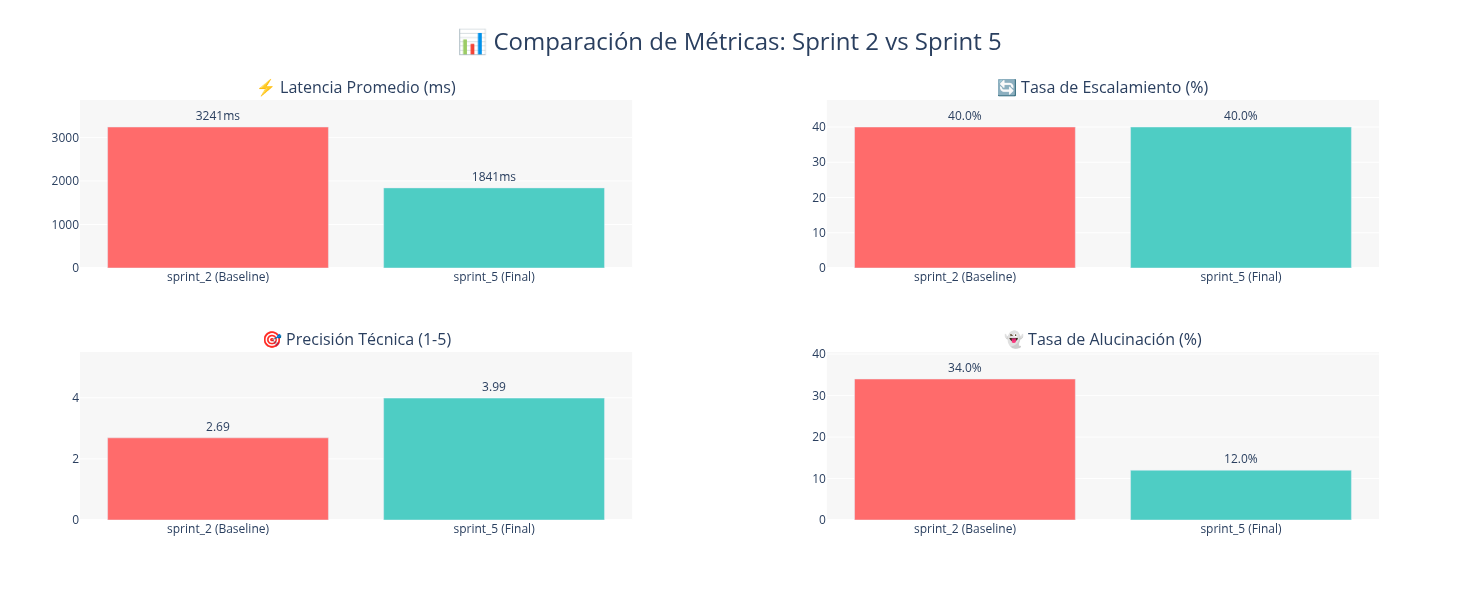

In [7]:
# Configurar tema y colores
colors = {
    sprint_a: "#FF6B6B",
    sprint_b: "#4ECDC4",
    "improvement": "#95E1D3",
    "decline": "#F38181"
}

# Crear figura con subplots
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "⚡ Latencia Promedio (ms)",
        "🔄 Tasa de Escalamiento (%)",
        "🎯 Precisión Técnica (1-5)",
        "👻 Tasa de Alucinación (%)"
    ),
    specs=[[{"type": "bar"}, {"type": "bar"}],
           [{"type": "bar"}, {"type": "bar"}]],
    horizontal_spacing=0.15,
    vertical_spacing=0.2
)

sprints = [f"{sprint_a}\n(Baseline)", f"{sprint_b}\n(Final)"]

# 1. Latencia Promedio
latencies = [sprint_a_metrics.get("avg_latency_ms", 0), sprint_b_metrics.get("avg_latency_ms", 0)]
fig.add_trace(
    go.Bar(
        x=sprints,
        y=latencies,
        marker_color=[colors[sprint_a], colors[sprint_b]],
        text=[f"{x:.0f}ms" for x in latencies],
        textposition="outside",
        name="Latencia"
    ),
    row=1, col=1
)

# 2. Tasa de Escalamiento
escalation = [sprint_a_metrics.get("escalation_rate", 0), sprint_b_metrics.get("escalation_rate", 0)]
fig.add_trace(
    go.Bar(
        x=sprints,
        y=escalation,
        marker_color=[colors[sprint_a], colors[sprint_b]],
        text=[f"{x:.1f}%" for x in escalation],
        textposition="outside",
        name="Escalamiento"
    ),
    row=1, col=2
)

# 3. Precisión Técnica
accuracy = [sprint_a_metrics.get("technical_accuracy", 0), sprint_b_metrics.get("technical_accuracy", 0)]
fig.add_trace(
    go.Bar(
        x=sprints,
        y=accuracy,
        marker_color=[colors[sprint_a], colors[sprint_b]],
        text=[f"{x:.2f}" for x in accuracy],
        textposition="outside",
        name="Precisión"
    ),
    row=2, col=1
)

# 4. Tasa de Alucinación
hallucination = [sprint_a_metrics.get("hallucination_rate", 0), sprint_b_metrics.get("hallucination_rate", 0)]
fig.add_trace(
    go.Bar(
        x=sprints,
        y=hallucination,
        marker_color=[colors[sprint_a], colors[sprint_b]],
        text=[f"{x:.1f}%" for x in hallucination],
        textposition="outside",
        name="Alucinación"
    ),
    row=2, col=2
)

# Actualizar layout
fig.update_layout(
    title={
        "text": "📊 Comparación de Métricas: Sprint 2 vs Sprint 5",
        "font": {"size": 24},
        "x": 0.5
    },
    showlegend=False,
    height=600,
    paper_bgcolor="white",
    plot_bgcolor="rgba(240,240,240,0.5)"
)

# Actualizar ejes Y para que muestren 0
fig.update_yaxes(range=[0, None], row=1, col=1)
fig.update_yaxes(range=[0, None], row=1, col=2)
fig.update_yaxes(range=[0, 5.5], row=2, col=1)
fig.update_yaxes(range=[0, None], row=2, col=2)

fig.show()

## 4. Análisis Detallado de Latencia

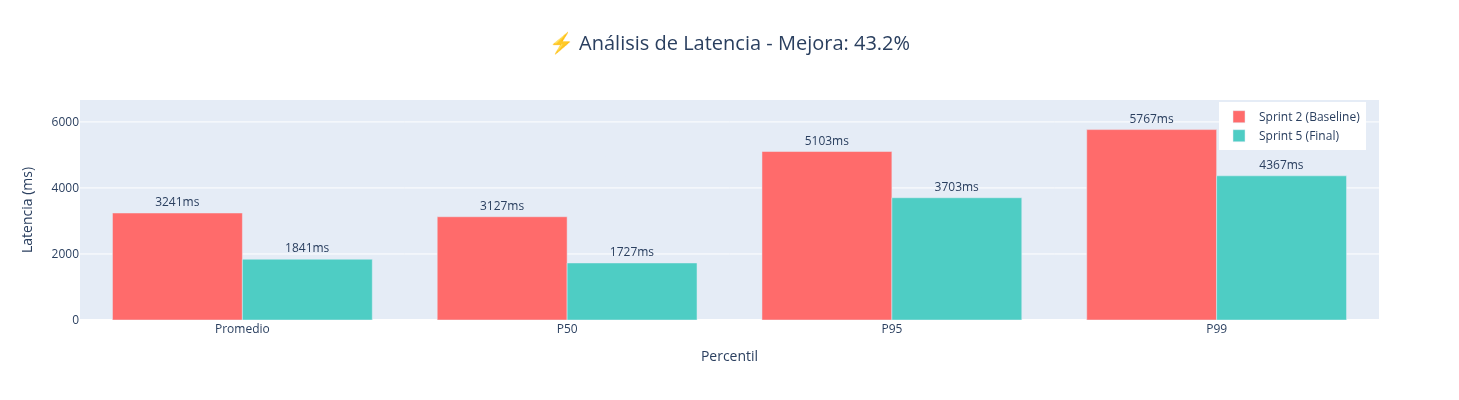

In [8]:
# Gráfico de latencia con percentiles
latency_metrics = ["avg_latency_ms", "p50_latency_ms", "p95_latency_ms", "p99_latency_ms"]
latency_labels = ["Promedio", "P50", "P95", "P99"]

sprint_a_latency = [sprint_a_metrics.get(m, 0) for m in latency_metrics]
sprint_b_latency = [sprint_b_metrics.get(m, 0) for m in latency_metrics]

fig_latency = go.Figure()

fig_latency.add_trace(go.Bar(
    name="Sprint 2 (Baseline)",
    x=latency_labels,
    y=sprint_a_latency,
    marker_color=colors[sprint_a],
    text=[f"{x:.0f}ms" for x in sprint_a_latency],
    textposition="outside"
))

fig_latency.add_trace(go.Bar(
    name="Sprint 5 (Final)",
    x=latency_labels,
    y=sprint_b_latency,
    marker_color=colors[sprint_b],
    text=[f"{x:.0f}ms" for x in sprint_b_latency],
    textposition="outside"
))

# Calcular mejora
improvement = ((sprint_a_latency[0] - sprint_b_latency[0]) / sprint_a_latency[0] * 100) if sprint_a_latency[0] > 0 else 0

fig_latency.update_layout(
    title={
        "text": f"⚡ Análisis de Latencia - Mejora: {improvement:.1f}%",
        "font": {"size": 20},
        "x": 0.5
    },
    xaxis_title="Percentil",
    yaxis_title="Latencia (ms)",
    barmode="group",
    height=400,
    paper_bgcolor="white",
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="right",
        x=0.99
    )
)

fig_latency.show()

## 5. Dimensiones de Evaluación Humana

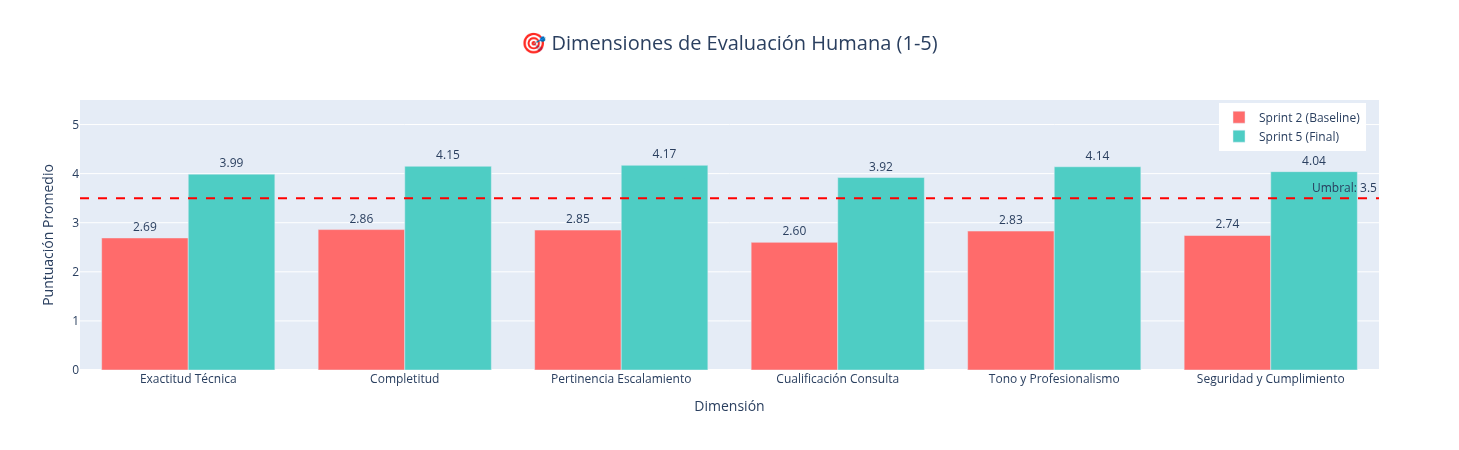

In [9]:
# Extraer dimensiones de evaluación humana
dimensions = ["accuracy", "completeness", "escalation_appropriateness", 
              "question_qualification", "tone_and_professionalism", "safety_and_compliance"]
dimension_labels = ["Exactitud\nTécnica", "Completitud", "Pertinencia\nEscalamiento",
                     "Cualificación\nConsulta", "Tono y\nProfesionalismo", "Seguridad y\nCumplimiento"]

def get_dimension_averages(data: dict) -> list:
    """Extrae promedios de dimensiones de evaluación humana."""
    if not data.get("human_eval"):
        return [0] * len(dimensions)
    dim_avgs = data["human_eval"].get("summary", {}).get("dimension_averages", {})
    return [dim_avgs.get(d, 0) for d in dimensions]

sprint_a_dims = get_dimension_averages(sprint_a_data)
sprint_b_dims = get_dimension_averages(sprint_b_data)

# Umbral de aprobación
threshold = 3.5

fig_dims = go.Figure()

# Sprint 2
fig_dims.add_trace(go.Bar(
    name="Sprint 2 (Baseline)",
    x=dimension_labels,
    y=sprint_a_dims,
    marker_color=colors[sprint_a],
    text=[f"{x:.2f}" for x in sprint_a_dims],
    textposition="outside"
))

# Sprint 5
fig_dims.add_trace(go.Bar(
    name="Sprint 5 (Final)",
    x=dimension_labels,
    y=sprint_b_dims,
    marker_color=colors[sprint_b],
    text=[f"{x:.2f}" for x in sprint_b_dims],
    textposition="outside"
))

# Línea de umbral
fig_dims.add_hline(
    y=threshold,
    line_dash="dash",
    line_color="red",
    annotation_text=f"Umbral: {threshold}",
    annotation_position="top right"
)

fig_dims.update_layout(
    title={
        "text": "🎯 Dimensiones de Evaluación Humana (1-5)",
        "font": {"size": 20},
        "x": 0.5
    },
    xaxis_title="Dimensión",
    yaxis_title="Puntuación Promedio",
    yaxis_range=[0, 5.5],
    barmode="group",
    height=450,
    paper_bgcolor="white",
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="right",
        x=0.99
    )
)

fig_dims.show()

## 6. Tabla Resumen de Métricas

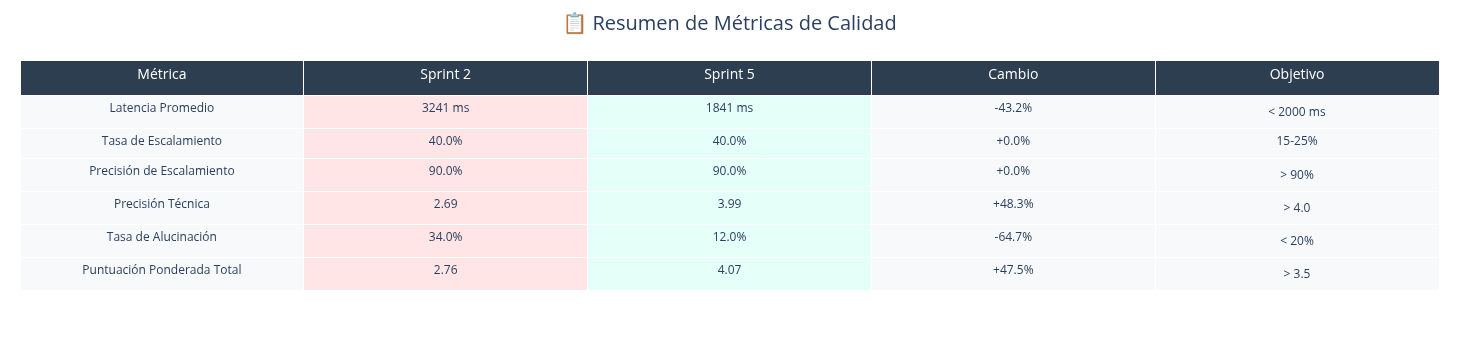

In [10]:
# Crear tabla resumen con comparaciones
def calculate_change(old_val: float, new_val: float, lower_is_better: bool = False) -> tuple:
    """Calcula el cambio porcentual y si es mejora."""
    if old_val == 0:
        return ("N/A", "neutral")
    change = ((new_val - old_val) / old_val) * 100
    if lower_is_better:
        is_improvement = change < 0
    else:
        is_improvement = change > 0
    
    emoji = "✅" if is_improvement else "⚠️"
    return (f"{change:+.1f}%", "good" if is_improvement else "bad")


summary_data = []

# Latencia
change, status = calculate_change(
    sprint_a_metrics.get("avg_latency_ms", 0),
    sprint_b_metrics.get("avg_latency_ms", 0),
    lower_is_better=True
)
summary_data.append({
    "Métrica": "Latencia Promedio",
    "Sprint 2": f"{sprint_a_metrics.get('avg_latency_ms', 0):.0f} ms",
    "Sprint 5": f"{sprint_b_metrics.get('avg_latency_ms', 0):.0f} ms",
    "Cambio": change,
    "Objetivo": "< 2000 ms"
})

# Tasa de Escalamiento
change, status = calculate_change(
    sprint_a_metrics.get("escalation_rate", 0),
    sprint_b_metrics.get("escalation_rate", 0)
)
summary_data.append({
    "Métrica": "Tasa de Escalamiento",
    "Sprint 2": f"{sprint_a_metrics.get('escalation_rate', 0):.1f}%",
    "Sprint 5": f"{sprint_b_metrics.get('escalation_rate', 0):.1f}%",
    "Cambio": change,
    "Objetivo": "15-25%"
})

# Precisión de Escalamiento
change, status = calculate_change(
    sprint_a_metrics.get("escalation_accuracy", 0),
    sprint_b_metrics.get("escalation_accuracy", 0)
)
summary_data.append({
    "Métrica": "Precisión de Escalamiento",
    "Sprint 2": f"{sprint_a_metrics.get('escalation_accuracy', 0):.1f}%",
    "Sprint 5": f"{sprint_b_metrics.get('escalation_accuracy', 0):.1f}%",
    "Cambio": change,
    "Objetivo": "> 90%"
})

# Precisión Técnica
change, status = calculate_change(
    sprint_a_metrics.get("technical_accuracy", 0),
    sprint_b_metrics.get("technical_accuracy", 0)
)
summary_data.append({
    "Métrica": "Precisión Técnica",
    "Sprint 2": f"{sprint_a_metrics.get('technical_accuracy', 0):.2f}",
    "Sprint 5": f"{sprint_b_metrics.get('technical_accuracy', 0):.2f}",
    "Cambio": change,
    "Objetivo": "> 4.0"
})

# Tasa de Alucinación
change, status = calculate_change(
    sprint_a_metrics.get("hallucination_rate", 0),
    sprint_b_metrics.get("hallucination_rate", 0),
    lower_is_better=True
)
summary_data.append({
    "Métrica": "Tasa de Alucinación",
    "Sprint 2": f"{sprint_a_metrics.get('hallucination_rate', 0):.1f}%",
    "Sprint 5": f"{sprint_b_metrics.get('hallucination_rate', 0):.1f}%",
    "Cambio": change,
    "Objetivo": "< 20%"
})

# Puntuación Ponderada Total
change, status = calculate_change(
    sprint_a_metrics.get("weighted_total_score", 0),
    sprint_b_metrics.get("weighted_total_score", 0)
)
summary_data.append({
    "Métrica": "Puntuación Ponderada Total",
    "Sprint 2": f"{sprint_a_metrics.get('weighted_total_score', 0):.2f}",
    "Sprint 5": f"{sprint_b_metrics.get('weighted_total_score', 0):.2f}",
    "Cambio": change,
    "Objetivo": "> 3.5"
})

summary_df = pd.DataFrame(summary_data)

# Crear tabla con formato
fig_table = go.Figure(data=[go.Table(
    header=dict(
        values=list(summary_df.columns),
        fill_color="#2C3E50",
        font=dict(color="white", size=14),
        align="center",
        height=35
    ),
    cells=dict(
        values=[summary_df[k].tolist() for k in summary_df.columns],
        fill_color=[
            ["#F8F9FA"] * len(summary_df),
            ["#FFE5E5"] * len(summary_df),
            ["#E5FFF9"] * len(summary_df),
            ["#F8F9FA"] * len(summary_df),
            ["#F8F9FA"] * len(summary_df),
        ],
        font=dict(size=12),
        align="center",
        height=30
    )
)])

fig_table.update_layout(
    title={
        "text": "📋 Resumen de Métricas de Calidad",
        "font": {"size": 20},
        "x": 0.5
    },
    height=350,
    margin=dict(l=20, r=20, t=60, b=20)
)

fig_table.show()

## 7. Gauge Charts - Estado Actual

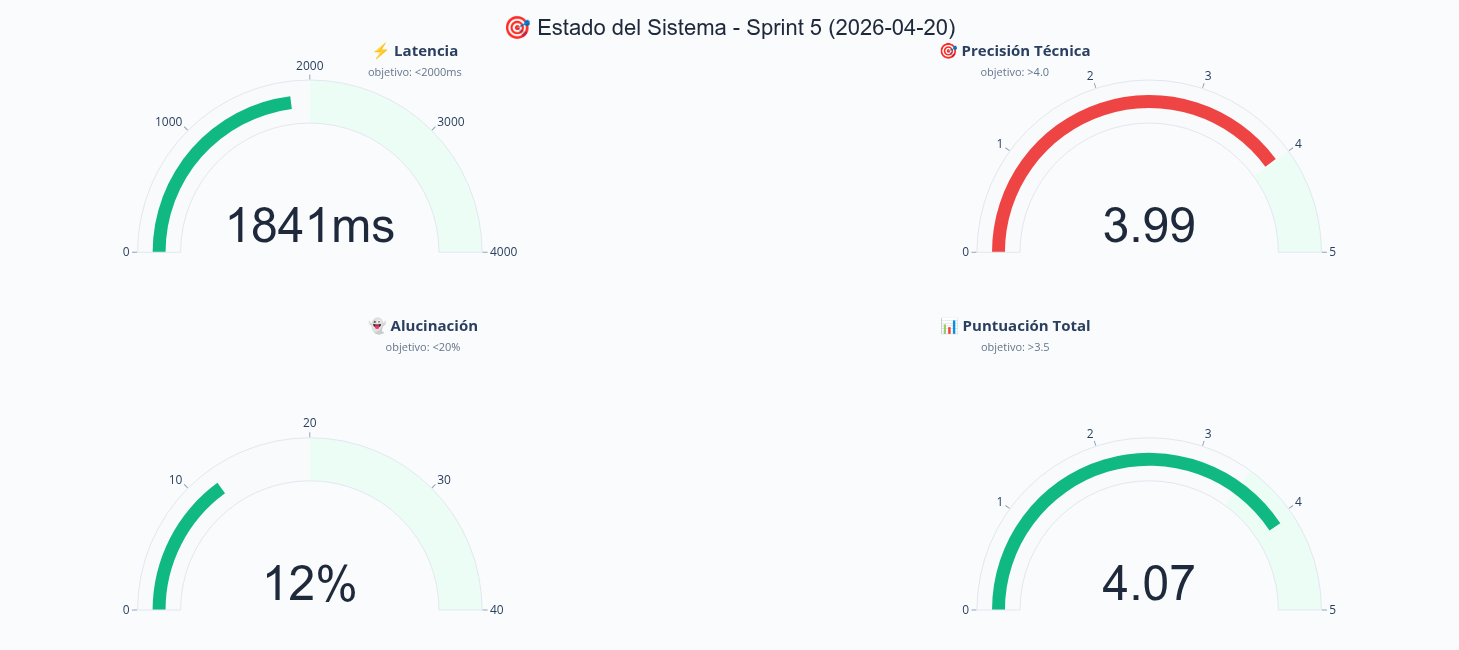

In [11]:
# Crear gauge charts para métricas clave del Sprint 5
fig_gauge = make_subplots(
    rows=2, cols=2,
    specs=[
        [{"type": "indicator"}, {"type": "indicator"}],
        [{"type": "indicator"}, {"type": "indicator"}]
    ],
    vertical_spacing=0.35,
    horizontal_spacing=0.2
)
def add_gauge(fig, row, col, value, maximum, threshold, unit=""):
    """Añade un gauge chart."""
    if value <= threshold if (unit == "ms" or unit == "%") else value >= threshold:
        color = "#10B981"
    else:
        color = "#EF4444"
    
    fig.add_trace(go.Indicator(
        mode="gauge+number",
        value=value,
        domain={"x": [0.05, 0.95], "y": [0.15, 0.95]},
        gauge={
            "axis": {"range": [0, maximum], "tickwidth": 1, "tickcolor": "#94A3B8", "dtick": maximum // 4},
            "bar": {"color": color, "thickness": 0.3},
            "bgcolor": "white",
            "bordercolor": "#E2E8F0",
            "borderwidth": 1,
            "steps": [
                {"range": [0, threshold], "color": "#F8FAFC"},
                {"range": [threshold, maximum], "color": "#ECFDF5"}
            ],
        },
        number={
            "suffix": unit,
            "font": {"size": 48, "color": "#1E293B", "family": "Inter, sans-serif"},
            "valueformat": ".0f" if (unit == "ms" or unit == "%") else ".2f"
        },
        title={"text": "", "font": {"size": 14}},
    ), row=row, col=col)
# Métricas del Sprint 5
latency = sprint_b_metrics.get("avg_latency_ms", 0)
tech_acc = sprint_b_metrics.get("technical_accuracy", 0)
halluc = sprint_b_metrics.get("hallucination_rate", 0)
total_score = sprint_b_metrics.get("weighted_total_score", 0)
add_gauge(fig_gauge, 1, 1, latency, 4000, 2000, "ms")
add_gauge(fig_gauge, 1, 2, tech_acc, 5, 4.0)
add_gauge(fig_gauge, 2, 1, halluc, 40, 20, "%")
add_gauge(fig_gauge, 2, 2, total_score, 5, 3.5)
# Usar anotaciones para títulos en lugar de subplot_titles (mejor control de posición)
gauge_annotations = [
    # Fila 1
    dict(
        text="<b>⚡ Latencia</b><br><span style='font-size:11px;color:#64748B'>objetivo: <2000ms</span>",
        x=0.24, y=1.08, xref="paper", yref="paper",
        showarrow=False, font=dict(size=15),
        align="center"
    ),
    dict(
        text="<b>🎯 Precisión Técnica</b><br><span style='font-size:11px;color:#64748B'>objetivo: >4.0</span>",
        x=0.76, y=1.08, xref="paper", yref="paper",
        showarrow=False, font=dict(size=15),
        align="center"
    ),
    # Fila 2
    dict(
        text="<b>👻 Alucinación</b><br><span style='font-size:11px;color:#64748B'>objetivo: <20%</span>",
        x=0.24, y=0.52, xref="paper", yref="paper",
        showarrow=False, font=dict(size=15),
        align="center"
    ),
    dict(
        text="<b>📊 Puntuación Total</b><br><span style='font-size:11px;color:#64748B'>objetivo: >3.5</span>",
        x=0.76, y=0.52, xref="paper", yref="paper",
        showarrow=False, font=dict(size=15),
        align="center"
    ),
]
fig_gauge.update_layout(
    title={
        "text": f"🎯 Estado del Sistema - Sprint 5 ({datetime.now().strftime('%Y-%m-%d')})",
        "font": {"size": 22, "color": "#1E293B", "family": "Inter, sans-serif"},
        "x": 0.5,
        "y": 0.97
    },
    height=650,
    width=1000,
    paper_bgcolor="#FAFBFC",
    margin=dict(l=30, r=30, t=80, b=40),
    annotations=gauge_annotations,
)
fig_gauge.show()

## 8. Exportar Reporte

In [12]:
print("💡 Para exportar el reporte:")
print("   - HTML interactivo: fig.write_html('evaluation/reports/quality_report.html')")
print("   - PDF: Instala kaleido y usa fig.write_image('report.pdf', format='pdf')")
print("   - PNG: fig.write_image('report.png', format='png')")

# Ejemplo de exportación
import os
os.makedirs("evaluation/reports", exist_ok=True)

print("\n✅ Reporte configurado para exportación")

💡 Para exportar el reporte:
   - HTML interactivo: fig.write_html('evaluation/reports/quality_report.html')
   - PDF: Instala kaleido y usa fig.write_image('report.pdf', format='pdf')
   - PNG: fig.write_image('report.png', format='png')

✅ Reporte configurado para exportación


In [13]:
# Información del reporte
print("\n" + "="*60)
print("📄 INFORMACIÓN DEL REPORTE")
print("="*60)
print(f"\n📅 Fecha de generación: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"\n📦 Datos Sprint 2:")
print(f"   - Fuente: {sprint_a_data['source']}")
if sprint_a_data.get('harness'):
    print(f"   - Commit: {sprint_a_data['harness'].get('git_commit', 'N/A')}")
    print(f"   - Queries: {sprint_a_data['harness'].get('total_queries', 'N/A')}")

print(f"\n📦 Datos Sprint 5:")
print(f"   - Fuente: {sprint_b_data['source']}")
if sprint_b_data.get('harness'):
    print(f"   - Commit: {sprint_b_data['harness'].get('git_commit', 'N/A')}")
    print(f"   - Queries: {sprint_b_data['harness'].get('total_queries', 'N/A')}")

print("\n" + "="*60)
print("✅ Reporte generado exitosamente")
print("="*60)


📄 INFORMACIÓN DEL REPORTE

📅 Fecha de generación: 2026-04-20 13:46:50

📦 Datos Sprint 2:
   - Fuente: mock
   - Commit: abc1234
   - Queries: 50

📦 Datos Sprint 5:
   - Fuente: mock
   - Commit: abc1234
   - Queries: 50

✅ Reporte generado exitosamente
